# Imports

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
import numpy as np
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)

# Reading Df

In [44]:
df = pd.read_csv('C:\\Users\\joaov\\OneDrive\\Área de Trabalho\\Python\\cloudwalk-challenge\\data\\raw\\transactional-sample.csv')
df

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False
...,...,...,...,...,...,...,...,...
3194,21323592,50493,49581,650486******4139,2019-11-01T13:05:34.054967,744.15,NaN,False
3195,21323593,9603,59275,528052******3611,2019-11-01T11:47:02.404963,1403.67,NaN,False
3196,21323594,57997,84486,522688******9874,2019-11-01T10:23:50.555604,1.55,NaN,False
3197,21323595,35930,7,544315******7773,2019-11-01T01:29:45.799767,359.68,NaN,False


# EDA

## Basic Info

In [9]:
df.shape

(3199, 8)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         3199 non-null   int64         
 1   merchant_id            3199 non-null   int64         
 2   user_id                3199 non-null   int64         
 3   card_number            3199 non-null   object        
 4   transaction_date       3199 non-null   datetime64[ns]
 5   transaction_amount     3199 non-null   float64       
 6   device_id              2369 non-null   float64       
 7   has_cbk                3199 non-null   bool          
 8   transaction_hour       3199 non-null   object        
 9   transaction_day        3199 non-null   object        
 10  transaction_period     3199 non-null   category      
 11  mean_amount_day        3199 non-null   float64       
 12  median_amount_day      3199 non-null   float64       
 13  dif

In [7]:
df['transaction_date'].min(), df['transaction_date'].max()

('2019-11-01T01:27:15.811098', '2019-12-01T23:16:32.812632')

**Here we can see that we are dealing with a database of a one month window**

### Target Rate

In [6]:
df['has_cbk'].value_counts(True)

has_cbk
False    0.877774
True     0.122226
Name: proportion, dtype: float64

## Visualizations

### Transaction Amount

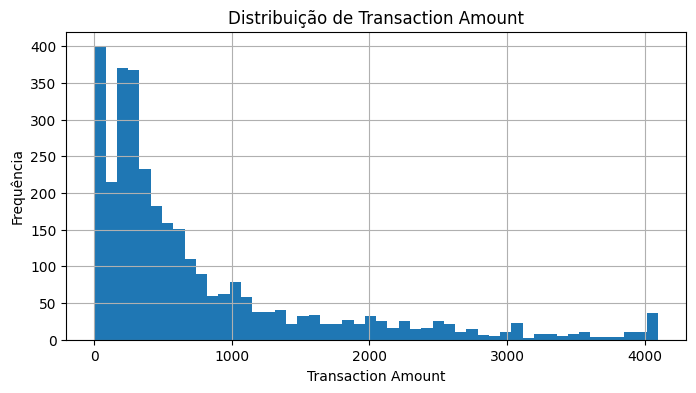

In [8]:
plt.figure(figsize=(8,4))
df['transaction_amount'].hist(bins=50)
plt.title("Distribuição de Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequência")
plt.show()

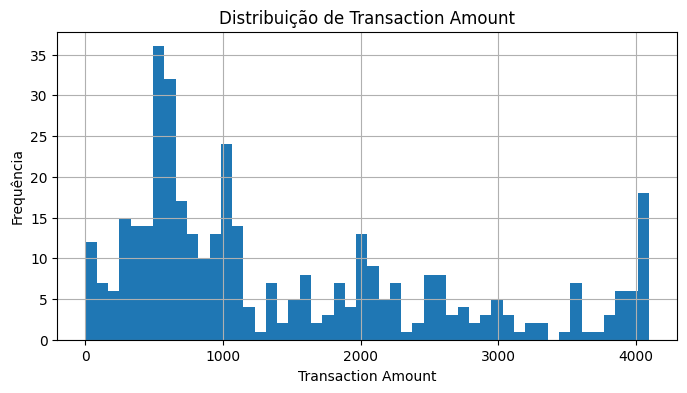

In [9]:
plt.figure(figsize=(8,4))
df[df['has_cbk'] == True]['transaction_amount'].hist(bins=50)
plt.title("Distribuição de Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequência")
plt.show()

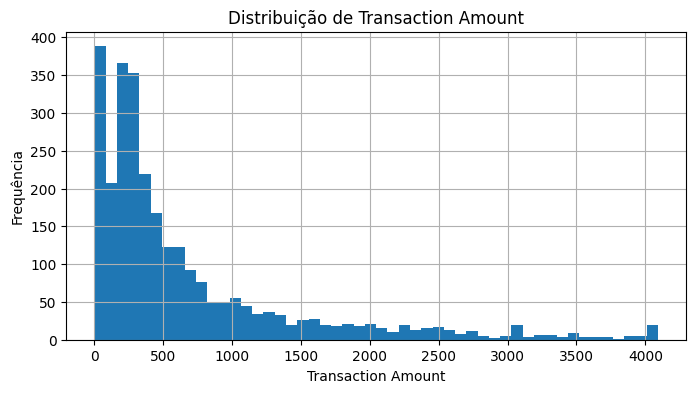

In [10]:
plt.figure(figsize=(8,4))
df[df['has_cbk'] == False]['transaction_amount'].hist(bins=50)
plt.title("Distribuição de Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequência")
plt.show()

**It can be clearly observed that the transactions amount follows a normal distribution when there is no fraud, and when there is, the curve is skewed.**

### Paretto Analysis

In [23]:
merchant_fraud = df.groupby('merchant_id').agg(
    fraud_rate=('has_cbk', 'mean'),
    fraud_count=('has_cbk', 'count'),
    transaction_count=('has_cbk', 'size')
).sort_values(by='fraud_rate', ascending=False).reset_index()

user_fraud = df.groupby('user_id').agg(
    fraud_rate=('has_cbk', 'mean'),
    fraud_count=('has_cbk', 'count'),
    transaction_count=('has_cbk', 'size'),
).sort_values(by='fraud_rate', ascending=False).reset_index()

device_fraud = df.groupby('device_id').agg(
    fraud_rate=('has_cbk', 'mean'),
    fraud_count=('has_cbk', 'count'),
    transaction_count=('has_cbk', 'size')
).sort_values(by='fraud_rate', ascending=False).reset_index()

merchant_worst = merchant_fraud[merchant_fraud['fraud_rate']>=0.8]
user_worst = user_fraud[user_fraud['fraud_rate']>=0.8]
device_worst = device_fraud[device_fraud['fraud_rate']>=0.8]

print(f"Merchants with fraud rate > 80%: {merchant_worst.shape[0]} ({merchant_worst.shape[0]/merchant_fraud.shape[0]*100:.2f}% of total merchants), with {merchant_worst['fraud_count'].sum() / df[df['has_cbk']==True].shape[0]*100:.2f}% of fraudulent transactions")
print(f"Users with fraud rate > 80%: {user_worst.shape[0]} ({user_worst.shape[0]/user_fraud.shape[0]*100:.2f}% of total users), with {user_worst['fraud_count'].sum() / df[df['has_cbk']==True].shape[0]*100:.2f}% of fraudulent transactions")
print(f"Devices with fraud rate > 80%: {device_worst.shape[0]} ({device_worst.shape[0]/device_fraud.shape[0]*100:.2f}% of total devices), with {device_worst['fraud_count'].sum() / df[df['has_cbk']==True].shape[0]*100:.2f}% of fraudulent transactions")

Merchants with fraud rate > 80%: 78 (4.44% of total merchants), with 70.84% of fraudulent transactions
Users with fraud rate > 80%: 127 (4.70% of total users), with 88.49% of fraudulent transactions
Devices with fraud rate > 80%: 110 (5.51% of total devices), with 72.63% of fraudulent transactions


**As expected, a minority of users, merchants, and devices commit most fraud, and this information can be used to build a blacklist.**

### Transaction volume X Fraud Rate Correlation

C:\Users\joaov\AppData\Local\Temp\ipykernel_14024\838916071.py:47: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



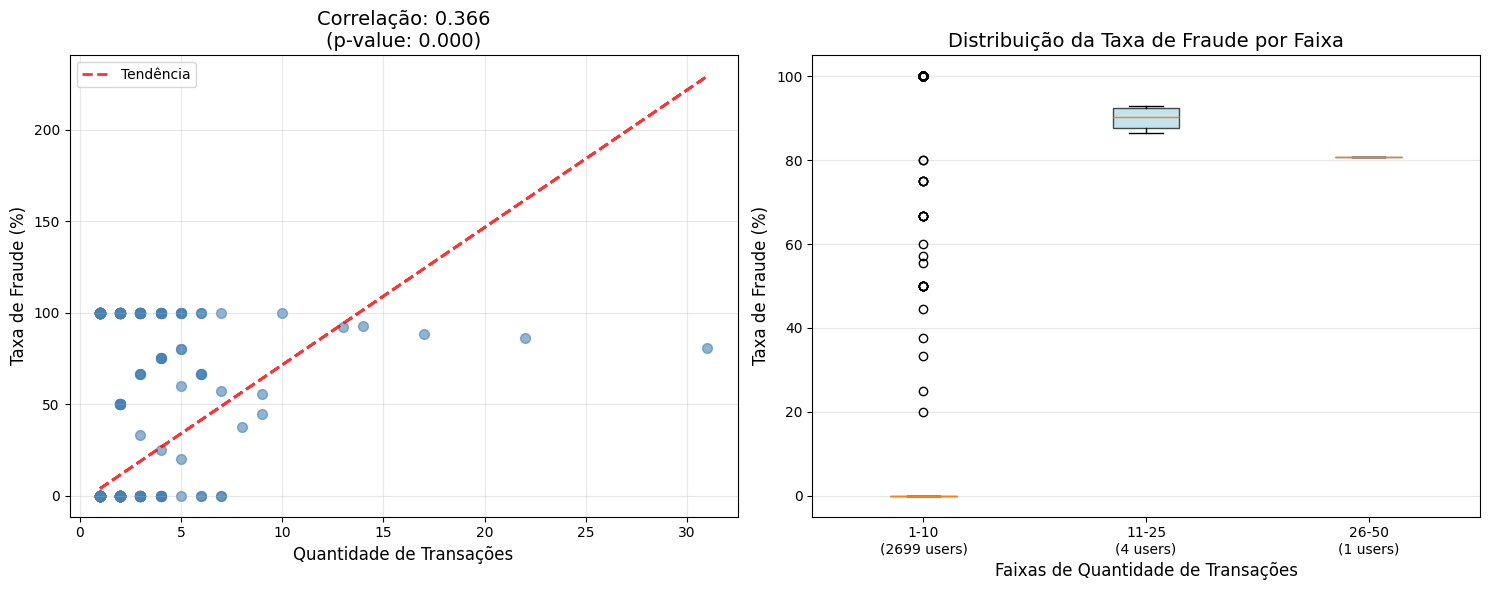

📊 RESUMO DA ANÁLISE
🔗 Correlação de Pearson: 0.3658
📈 Significância estatística: SIGNIFICATIVA (p=0.0000)

📋 Interpretação da Correlação:
   → MODERADA - Relação linear moderada
   → Direção: POSITIVA - Mais transações → Maior taxa de fraude

📊 ESTATÍSTICAS POR FAIXA:
   1-10: 5.0% média, 0.0% mediana (2699 usuários)
   11-25: 89.9% média, 90.3% mediana (4 usuários)
   26-50: 80.7% média, 80.7% mediana (1 usuários)


In [ ]:
# Configuração
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: Scatter Plot com linha de tendência
axes[0].scatter(user_fraud['transaction_count'], 
                user_fraud['fraud_rate'] * 100,  # converter para %
                alpha=0.6, 
                s=50,
                color='steelblue')

# Adicionar linha de tendência
z = np.polyfit(user_fraud['transaction_count'], user_fraud['fraud_rate'] * 100, 1)
p = np.poly1d(z)
axes[0].plot(user_fraud['transaction_count'], p(user_fraud['transaction_count']), 
             "r--", alpha=0.8, linewidth=2, label=f'Tendência')

# Calcular correlação
correlation, p_value = pearsonr(user_fraud['transaction_count'], user_fraud['fraud_rate'])

axes[0].set_xlabel('Quantidade de Transações', fontsize=12)
axes[0].set_ylabel('Taxa de Fraude (%)', fontsize=12)
axes[0].set_title(f'Correlação: {correlation:.3f}\n(p-value: {p_value:.3f})', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# GRÁFICO 2: Box Plot por Faixas de Transação
# Criar faixas
user_fraud['faixa_transacao'] = pd.cut(user_fraud['transaction_count'], 
                                      bins=[0, 10, 25, 50, 100, float('inf')], 
                                      labels=['1-10', '11-25', '26-50', '51-100', '100+'])

# Preparar dados para boxplot
box_data = []
box_labels = []
for faixa in user_fraud['faixa_transacao'].cat.categories:
    dados_faixa = user_fraud[user_fraud['faixa_transacao'] == faixa]['fraud_rate'] * 100
    if len(dados_faixa) > 0:
        box_data.append(dados_faixa.values)
        box_labels.append(f'{faixa}\n({len(dados_faixa)} users)')

bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)

# Colorir os boxplots
colors = ['lightcoral', 'lightblue', 'lightgreen', 'lightyellow', 'lightpink']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Faixas de Quantidade de Transações', fontsize=12)
axes[1].set_ylabel('Taxa de Fraude (%)', fontsize=12)
axes[1].set_title('Distribuição da Taxa de Fraude por Faixa', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# RESUMO ESTATÍSTICO
print("=" * 50)
print("📊 RESUMO DA ANÁLISE")
print("=" * 50)

print(f"🔗 Correlação de Pearson: {correlation:.4f}")
if p_value < 0.05:
    significancia = "SIGNIFICATIVA"
else:
    significancia = "NÃO SIGNIFICATIVA"
print(f"📈 Significância estatística: {significancia} (p={p_value:.4f})")

print(f"\n📋 Interpretação da Correlação:")
if abs(correlation) < 0.1:
    interpretacao = "MUITO FRACA - Praticamente inexistente"
elif abs(correlation) < 0.3:
    interpretacao = "FRACA - Pouca relação linear"
elif abs(correlation) < 0.5:
    interpretacao = "MODERADA - Relação linear moderada"
elif abs(correlation) < 0.7:
    interpretacao = "FORTE - Relação linear forte"
else:
    interpretacao = "MUITO FORTE - Relação linear muito forte"

print(f"   → {interpretacao}")

if correlation > 0:
    direcao = "POSITIVA - Mais transações → Maior taxa de fraude"
elif correlation < 0:
    direcao = "NEGATIVA - Mais transações → Menor taxa de fraude"
else:
    direcao = "NEUTRA - Sem direção definida"

print(f"   → Direção: {direcao}")

# Estatísticas por faixa
print(f"\n📊 ESTATÍSTICAS POR FAIXA:")
resumo_faixas = user_fraud.groupby('faixa_transacao', observed=True).agg({
    'fraud_rate': ['mean', 'median', 'count']
}).round(4)

for faixa in resumo_faixas.index:
    media = resumo_faixas.loc[faixa, ('fraud_rate', 'mean')] * 100
    mediana = resumo_faixas.loc[faixa, ('fraud_rate', 'median')] * 100
    qtd = resumo_faixas.loc[faixa, ('fraud_rate', 'count')]
    print(f"   {faixa}: {media:.1f}% média, {mediana:.1f}% mediana ({qtd} usuários)")

**It is inconclusive to say for sure the relationship between the number of transactions and the fraud rate, due to the concentrated distribution of transaction volume.**

# Feature Engineering

## Features based on temporal data

In [45]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_hour'] = df['transaction_date'].dt.strftime('%H')
df['transaction_day'] = df['transaction_date'].dt.strftime('%A')
df['transaction_period'] = pd.cut(df['transaction_hour'].astype(int), 
                                  bins=[-1, 5, 11, 17, 23],
                                  labels=['Dawn', 'Morning', 'Afternoon', 'Evening'])

In [46]:
mean_by_day = df.groupby('transaction_day')['transaction_amount'].mean().rename('mean_amount_day')
median_by_day = df.groupby('transaction_day')['transaction_amount'].median().rename('median_amount_day')

df = df.merge(mean_by_day, on='transaction_day', how='left')
df = df.merge(median_by_day, on='transaction_day', how='left')

df['diff_from_mean_day'] = df['transaction_amount'] - df['mean_amount_day']
df['ratio_to_mean_day'] = df['transaction_amount'] / df['mean_amount_day']

In [47]:
mean_by_period = df.groupby('transaction_period')['transaction_amount'].mean().rename('mean_amount_period')
df = df.merge(mean_by_period, on='transaction_period', how='left')

df['diff_from_mean_period'] = df['transaction_amount'] - df['mean_amount_period']
df['ratio_to_mean_period'] = df['transaction_amount'] / df['mean_amount_period']

C:\Users\joaov\AppData\Local\Temp\ipykernel_12012\215955194.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_period = df.groupby('transaction_period')['transaction_amount'].mean().rename('mean_amount_period')


In [48]:
mean_by_user = df.groupby('user_id')['transaction_amount'].mean().rename('mean_amount_user')
median_by_user = df.groupby('user_id')['transaction_amount'].median().rename('median_amount_user')

df = df.merge(mean_by_user, on='user_id', how='left')
df = df.merge(median_by_user, on='user_id', how='left')

df['diff_from_user_mean'] = df['transaction_amount'] - df['mean_amount_user']
df['ratio_to_user_mean'] = df['transaction_amount'] / df['mean_amount_user']

## Analysis of Engineered Features

<Axes: xlabel='transaction_day', ylabel='transaction_count'>

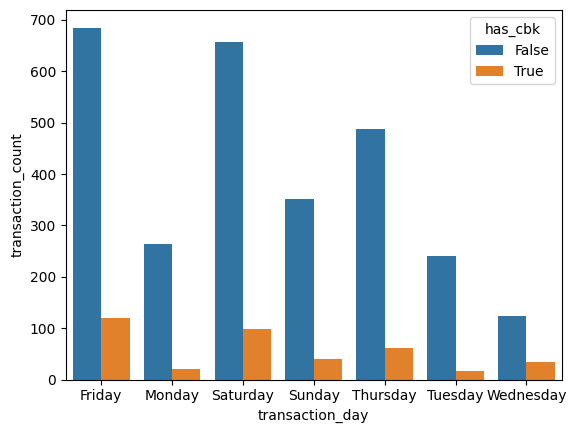

In [21]:
a = df.groupby(['transaction_day', 'has_cbk']).agg(transaction_count=("transaction_amount", 'count'), transaction_mean=("transaction_amount", 'mean')).reset_index()

# plot barplot
sns.barplot(x="transaction_day",
           y="transaction_count",
           hue="has_cbk",
           data=a)

<Axes: xlabel='transaction_day', ylabel='transaction_mean'>

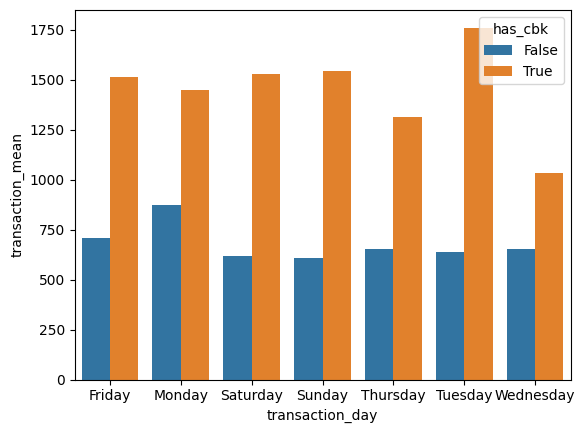

In [22]:
sns.barplot(x="transaction_day",
           y="transaction_mean",
           hue="has_cbk",
           data=a)

In [ ]:
day_group = df.groupby(['transaction_day']).agg(fraud_rate=("has_cbk", 'mean'), transaction_count=("transaction_amount", 'count')).reset_index()
day_group


,transaction_day,fraud_rate,transaction_count
0,Friday,0.149068,805
1,Monday,0.070423,284
2,Saturday,0.130952,756
3,Sunday,0.104592,392
4,Thursday,0.111111,549
5,Tuesday,0.062500,256
6,Wednesday,0.216561,157


C:\Users\joaov\AppData\Local\Temp\ipykernel_9032\3754572972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['transaction_period', 'has_cbk']).agg(transaction_count=("transaction_amount", 'count'), transaction_mean=("transaction_amount", 'mean')).reset_index()


<Axes: xlabel='transaction_period', ylabel='transaction_count'>

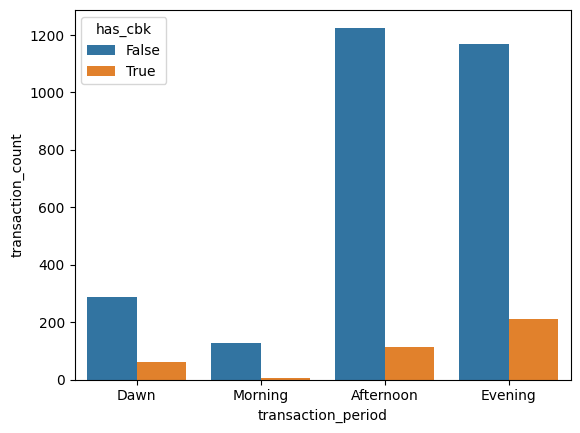

In [23]:
a = df.groupby(['transaction_period', 'has_cbk']).agg(transaction_count=("transaction_amount", 'count'), transaction_mean=("transaction_amount", 'mean')).reset_index()

# plot barplot
sns.barplot(x="transaction_period",
           y="transaction_count",
           hue="has_cbk",
           data=a)

<Axes: xlabel='transaction_period', ylabel='transaction_mean'>

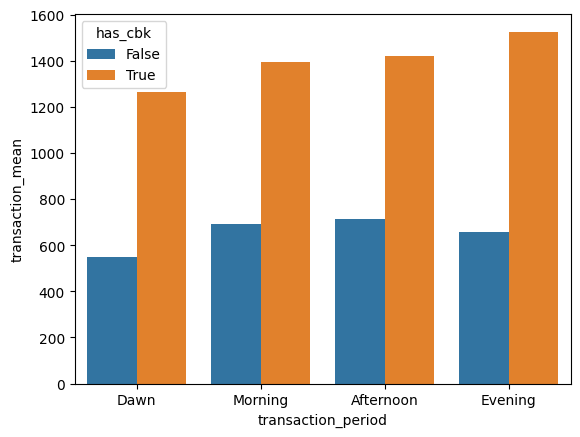

In [24]:
sns.barplot(x="transaction_period",
           y="transaction_mean",
           hue="has_cbk",
           data=a)

In [116]:
period_group = df.groupby(['transaction_period']).agg(fraud_rate=("has_cbk", 'mean'), transaction_count=("transaction_amount", 'count')).reset_index()
period_group


C:\Users\joaov\AppData\Local\Temp\ipykernel_14024\1375826556.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,transaction_period,fraud_rate,transaction_count
0,Dawn,0.173410,346
1,Morning,0.044776,134
2,Afternoon,0.085757,1341
3,Evening,0.152395,1378


### Analysis of KS and Total Variation of each individual Feature

In [38]:
def plot_cols(df, tgt_col='has_cbk'):

    num_cols = df.select_dtypes(include=['float', 'int']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    for col in cat_cols:
        if col != tgt_col:
            # Crosstab normalizado por coluna -> distribuição condicional P(valor|tgt_col)
            ct = pd.crosstab(df[col], df[tgt_col], normalize='columns') * 100
            ct.plot(kind='bar', figsize=(10, 5))
            plt.xticks(rotation=0)
            plt.title(f"{col} grouped by {tgt_col} (Percentage within Flag)")
            plt.ylabel("Percentage (%)")
            plt.show()

            # Calcular Total Variation Distance (TVD) se houver exatamente 2 classes
            if ct.shape[1] == 2:
                dist1 = ct.iloc[:, 0] / 100  # transformar em proporção
                dist2 = ct.iloc[:, 1] / 100
                tvd = 0.5 * (dist1 - dist2).abs().sum()
                print(f"Total Variation Distance for '{col}': {tvd:.2%}")


    for col in num_cols:
        plt.figure(figsize=(10, 5))
        for flag in df[tgt_col].unique():
            subset = df[df[tgt_col] == flag][col]
            sns.histplot(subset, kde=True, stat='percent', label=str(flag), bins=30, alpha=0.5)
        plt.title(f"{col} Distribution by {tgt_col} (Percentage of Dataset)")
        plt.xlabel(col)
        plt.ylabel("Percentage (%)")
        plt.legend(title=tgt_col)
        plt.show()
        
        # KS test
        flag_values = df[tgt_col].unique()
        data1 = df[df[tgt_col] == flag_values[0]][col].dropna()
        data2 = df[df[tgt_col] == flag_values[1]][col].dropna()
        ks_stat, ks_pvalue = ks_2samp(data1, data2)
        print(f"KS statistic for {col}: {ks_stat:.2%}, p-value: {ks_pvalue:.2f}")

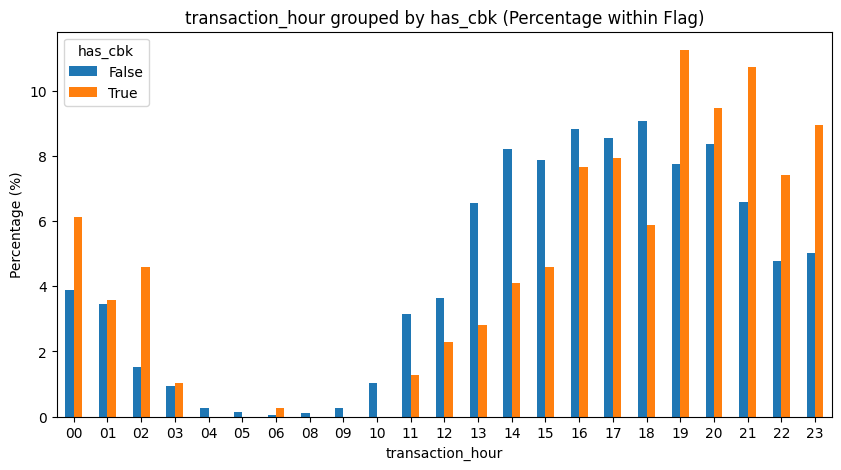

Total Variation Distance for 'transaction_hour': 21.08%


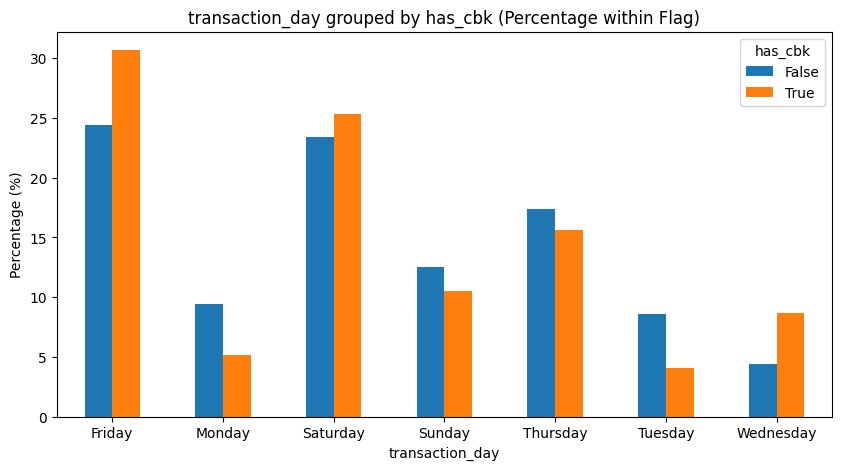

Total Variation Distance for 'transaction_day': 12.53%


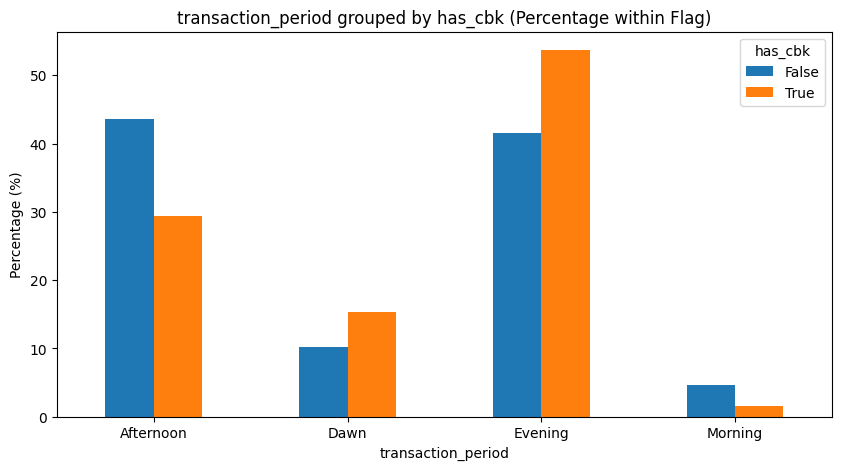

Total Variation Distance for 'transaction_period': 17.27%


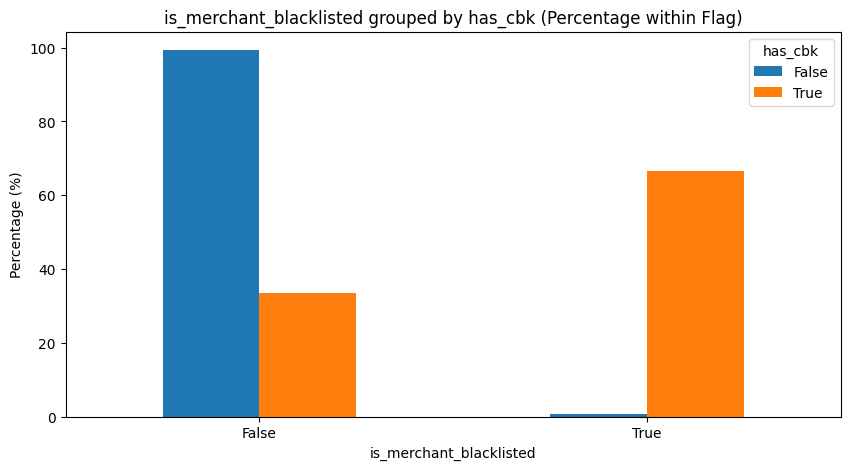

Total Variation Distance for 'is_merchant_blacklisted': 65.89%


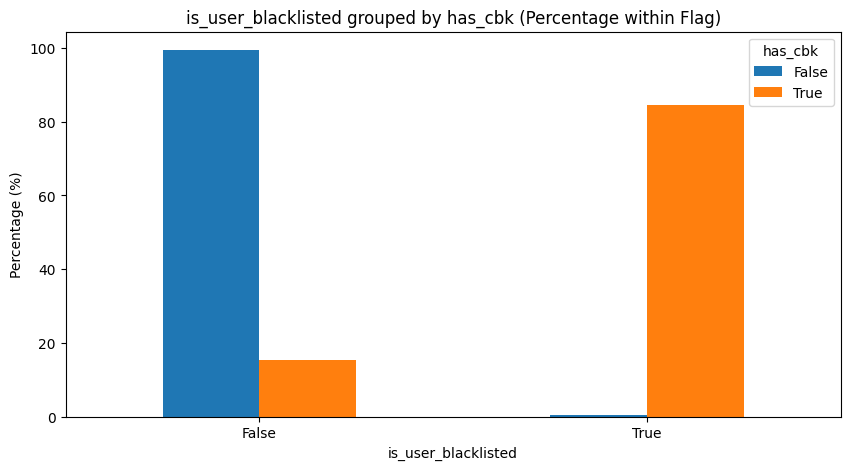

Total Variation Distance for 'is_user_blacklisted': 84.12%


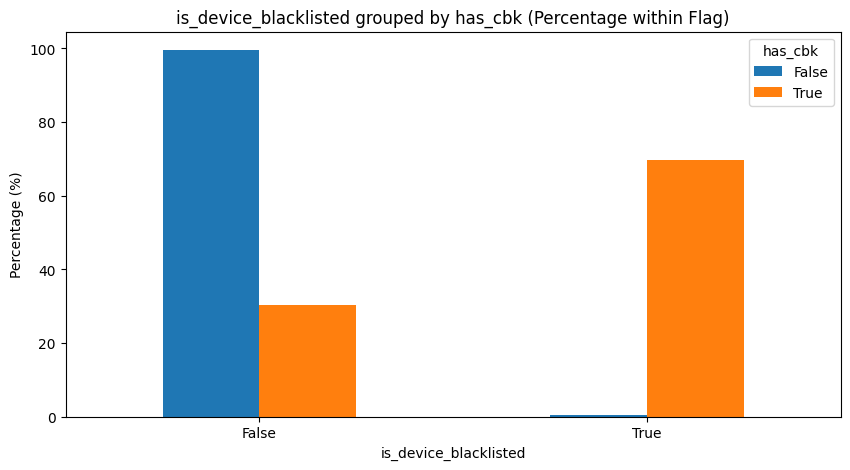

Total Variation Distance for 'is_device_blacklisted': 69.43%


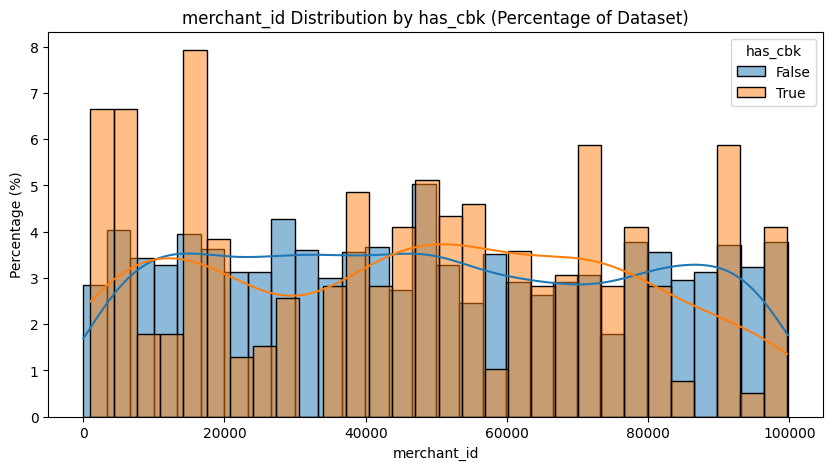

KS statistic for merchant_id: 8.90%, p-value: 0.01


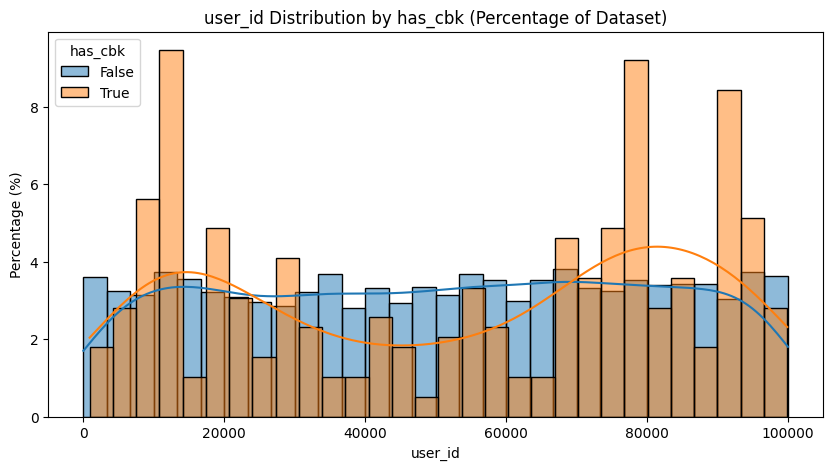

KS statistic for user_id: 13.23%, p-value: 0.00


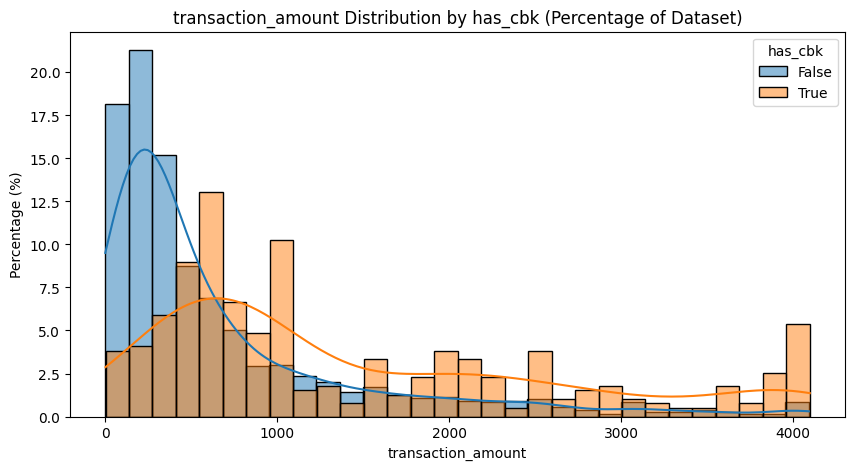

KS statistic for transaction_amount: 43.40%, p-value: 0.00


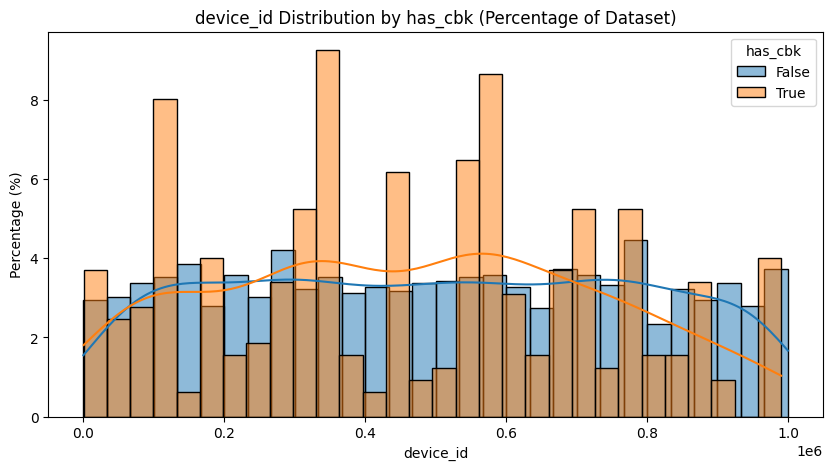

KS statistic for device_id: 10.85%, p-value: 0.00


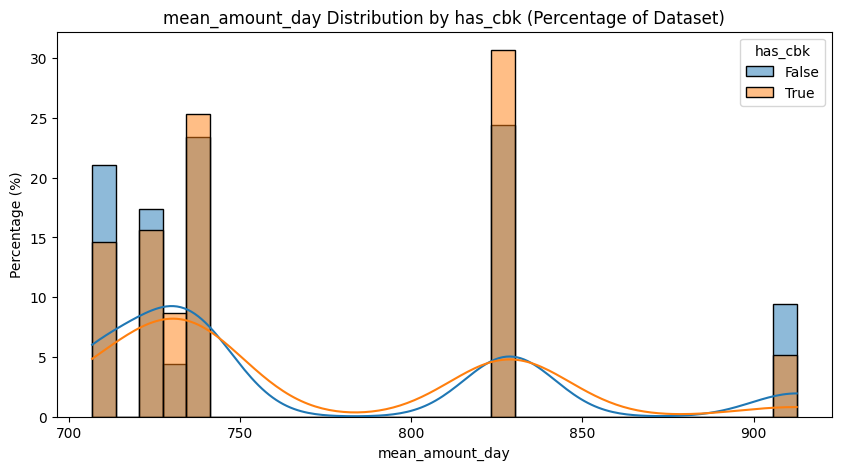

KS statistic for mean_amount_day: 8.25%, p-value: 0.02


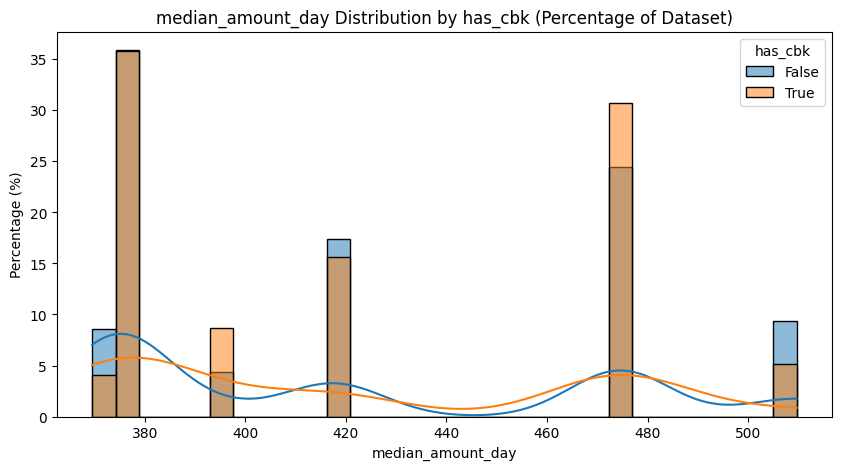

KS statistic for median_amount_day: 6.47%, p-value: 0.11


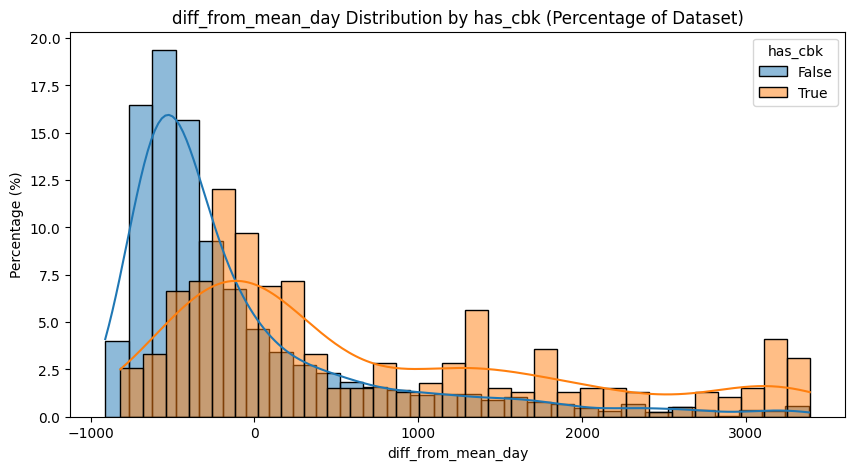

KS statistic for diff_from_mean_day: 42.88%, p-value: 0.00


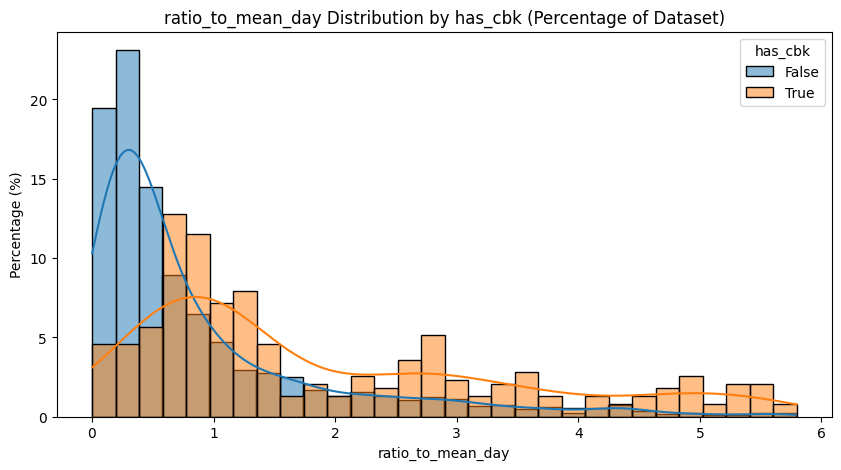

KS statistic for ratio_to_mean_day: 43.66%, p-value: 0.00


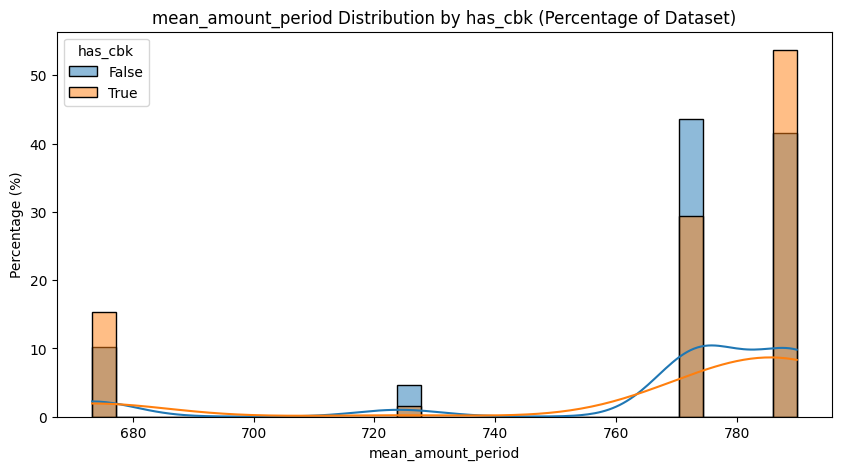

KS statistic for mean_amount_period: 12.11%, p-value: 0.00


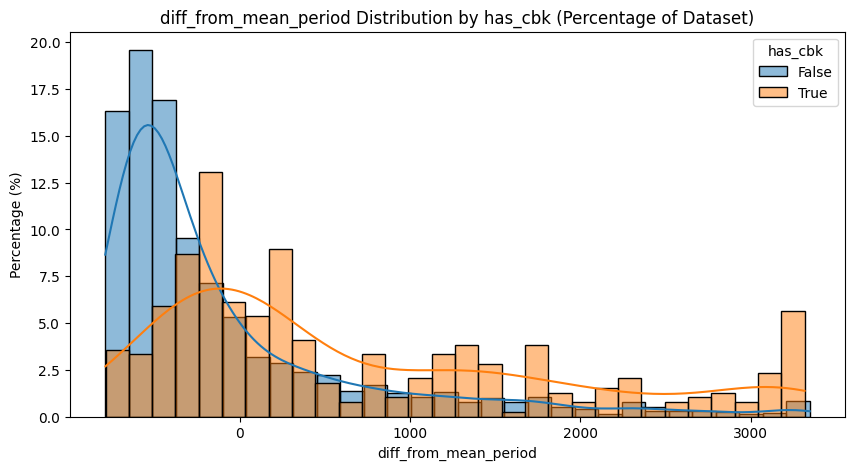

KS statistic for diff_from_mean_period: 43.02%, p-value: 0.00


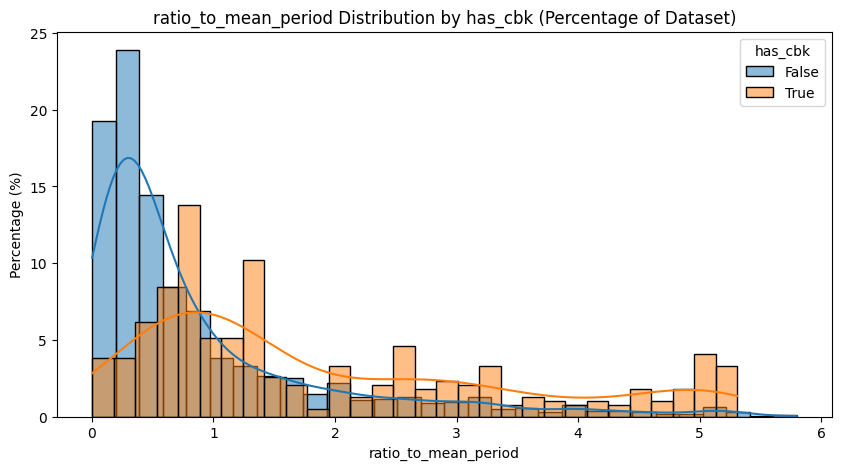

KS statistic for ratio_to_mean_period: 43.59%, p-value: 0.00


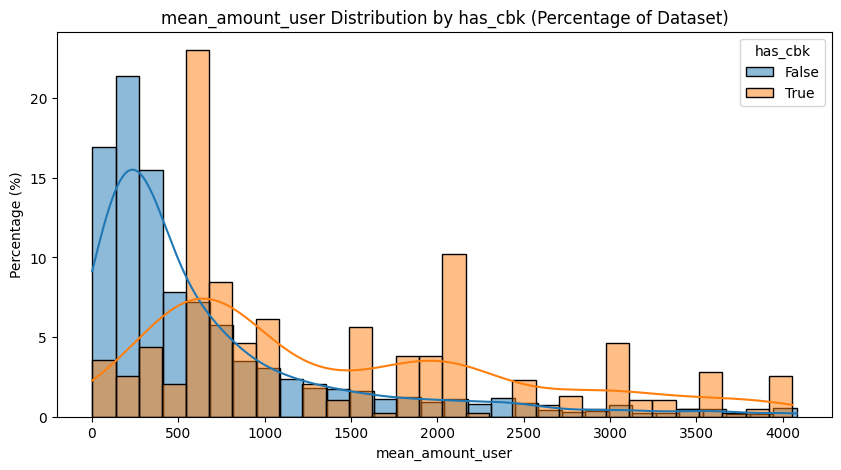

KS statistic for mean_amount_user: 50.07%, p-value: 0.00


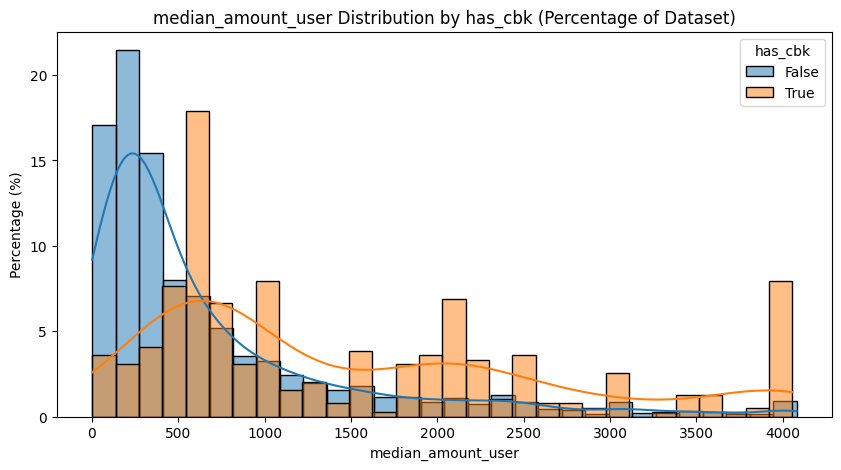

KS statistic for median_amount_user: 45.87%, p-value: 0.00


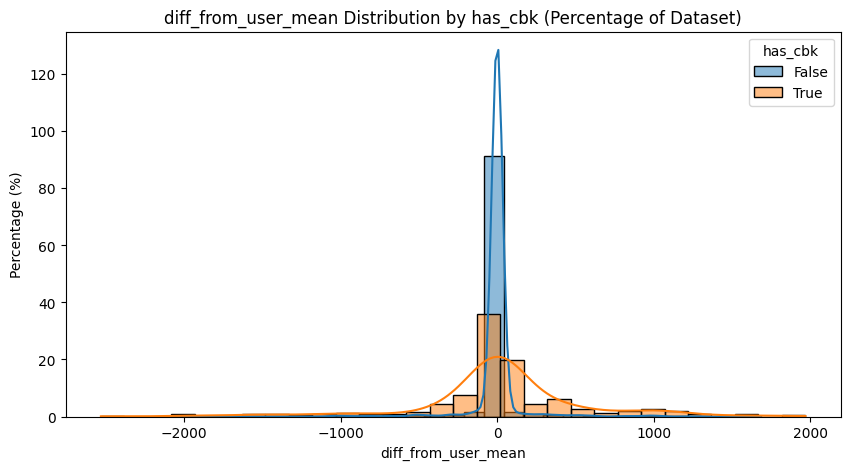

KS statistic for diff_from_user_mean: 40.29%, p-value: 0.00


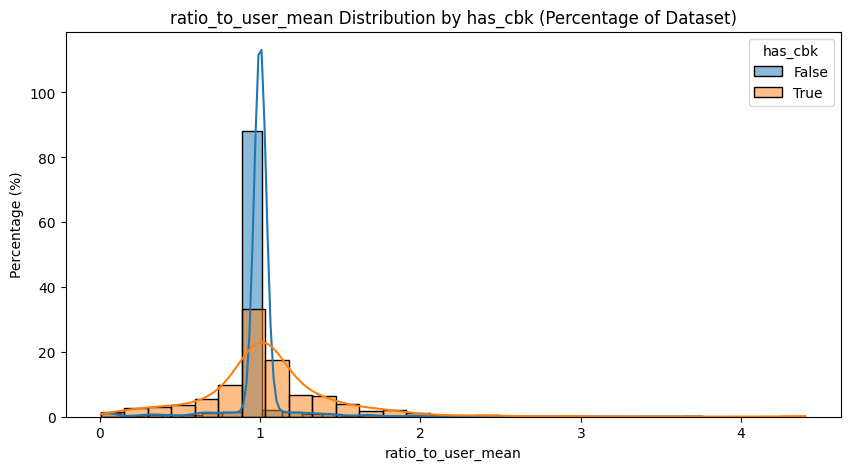

KS statistic for ratio_to_user_mean: 40.11%, p-value: 0.00


In [41]:
plot_cols(df.drop(['transaction_id', 'card_number'], axis=1), tgt_col='has_cbk')

# Saving Processed Database

In [50]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['has_cbk'], random_state=42)

In [54]:
train_df.to_csv('C:\\Users\\joaov\\OneDrive\\Área de Trabalho\\Python\\cloudwalk-challenge\\data\\processed\\train_processed.csv', index=False)
test_df.to_csv('C:\\Users\\joaov\\OneDrive\\Área de Trabalho\\Python\\cloudwalk-challenge\\data\\processed\\test_processed.csv', index=False)